   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  
Missing Values before cleaning:
pclass        0
age         177
sex           0
fare          0
survived      0
dtype: int64
pclass      0
age         0
sex         0
fare        0
survived    0
dtype: int64
     pclass

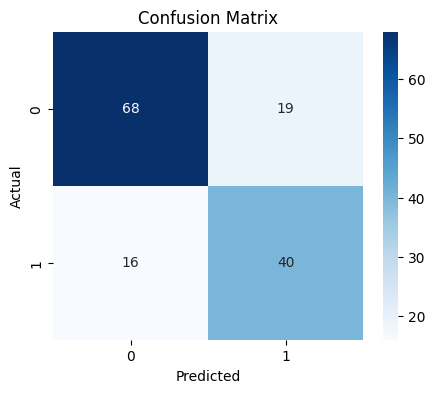

Prediction: [1]
Prediction: [0]
Probability: [[0.95345996 0.04654004]]


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# step 2 create database

df = sns.load_dataset ('titanic')
print(df.head())

# step 3 - select required columns

df = df[['pclass','age','sex','fare','survived']]

# step 4 -  check missing values
print('Missing Values before cleaning:')
print(df.isnull().sum())

# step 5 -  drop rows containing missing values
df = df.dropna()
print(df.isnull().sum())

# step 6 - convert male/female into numbers
df['sex'] = df['sex'].map({
    'male':0,
    'female':1
})
print(df)

# step 7 - features and targets
X = df[['pclass','age','sex','fare']]
y = df['survived']

# step 8 - split the dataset
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

# step 9 - create model
model = LogisticRegression(max_iter=1000)

# why are we using max_iter - LoR trained iteratively, the model keeps adjusting its
# cofficients until it coverages
# max iter-maximum no of iterations the model is allowed  to perform,
# model = Logisticregression(max_iter = 1000) means the model can take up to 1000 iterartion to find a solution

# step 10 train the model
model.fit(X_train,y_train)

#step 11 -  prediction
y_pred = model.predict(X_test)

# step 12 - Accuracy
print("Accuracy:",accuracy_score(y_test,y_pred))

# step 13 - confussion_matrix
cm = confusion_matrix(y_test,y_pred)

# print heatmap
plt.figure(figsize=(5,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# predict new passenger

new_passenger = pd.DataFrame({
    'pclass':[1],
    'sex':[1],
    'age':[25],
    'fare':[100]
})

new_passenger = new_passenger[X.columns]
prediction = model.predict(new_passenger)
print('Prediction:',prediction)

#predict another passenger

new_passanger = pd.DataFrame ({
                            'pclass' : [3],
                            'sex'    : [0],
                            'age'    : [45],
                            'fare'   : [8]
                            })
new_passanger = new_passanger[X.columns]
prediction = model.predict(new_passanger)
print('Prediction:',prediction)


#probability of survial (most important)
probability = model.predict_proba(new_passanger)
print('Probability:',probability)

## New Classification Problem: Breast Cancer Diagnosis

Let's apply a similar machine learning workflow to the Breast Cancer dataset. This dataset involves predicting whether a tumor is malignant or benign based on various features. We'll use Logistic Regression again.

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load the dataset
cancer = load_breast_cancer()

# Create a DataFrame
df_cancer = pd.DataFrame(data=cancer.data, columns=cancer.feature_names)
df_cancer['target'] = cancer.target

print('Breast Cancer Dataset Head:')
display(df_cancer.head())

print('\nMissing Values:')
print(df_cancer.isnull().sum())

Breast Cancer Dataset Head:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



Missing Values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [7]:
# Define features (X) and target (y)
X_cancer = df_cancer.drop('target', axis=1)
y_cancer = df_cancer['target']

# Scale the features (important for Logistic Regression when features have different scales)
scaler = StandardScaler()
X_cancer_scaled = scaler.fit_transform(X_cancer)

# Split the dataset into training and testing sets
X_train_cancer, X_test_cancer, y_train_cancer, y_test_cancer = train_test_split(X_cancer_scaled, y_cancer, test_size=0.2, random_state=42)

Accuracy: 0.9736842105263158

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



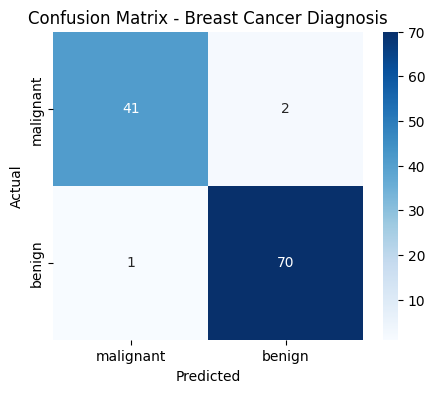

In [8]:
# Create and train a Logistic Regression model
model_cancer = LogisticRegression(max_iter=1000)
model_cancer.fit(X_train_cancer, y_train_cancer)

# Make predictions on the test set
y_pred_cancer = model_cancer.predict(X_test_cancer)

# Evaluate the model
print('Accuracy:', accuracy_score(y_test_cancer, y_pred_cancer))
print('\nClassification Report:')
print(classification_report(y_test_cancer, y_pred_cancer))

# Confusion Matrix
cm_cancer = confusion_matrix(y_test_cancer, y_pred_cancer)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_cancer,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=cancer.target_names,
    yticklabels=cancer.target_names
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Breast Cancer Diagnosis')
plt.show()

In [9]:
# Example of predicting a new 'patient'
# For demonstration, let's create a synthetic patient data point with the same number of features
# Note: This would typically come from new, unseen patient data and would also need to be scaled.

# Get a sample feature set (e.g., the first entry from the original scaled data)
sample_patient_features = X_cancer_scaled[0].reshape(1, -1) # Reshape for single prediction

# Predict the diagnosis (0 = malignant, 1 = benign)
prediction_cancer = model_cancer.predict(sample_patient_features)
probability_cancer = model_cancer.predict_proba(sample_patient_features)

print(f"Sample patient features (first patient in dataset, scaled): {sample_patient_features.flatten()[:5]}...")
print(f"Predicted Diagnosis for sample patient: {cancer.target_names[prediction_cancer[0]]}")
print(f"Probability of diagnosis (Malignant/Benign): {probability_cancer[0]}")

Sample patient features (first patient in dataset, scaled): [ 1.09706398 -2.07333501  1.26993369  0.9843749   1.56846633]...
Predicted Diagnosis for sample patient: malignant
Probability of diagnosis (Malignant/Benign): [9.99999994e-01 5.51056886e-09]


In [ ]:
# Likelihood Function
# measures the accuracy of logistic regression algorithm

In [ ]:
# it is useful when data is exhibited a non linear relationship allowing the model to fit a curve to the data